# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [4]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import math


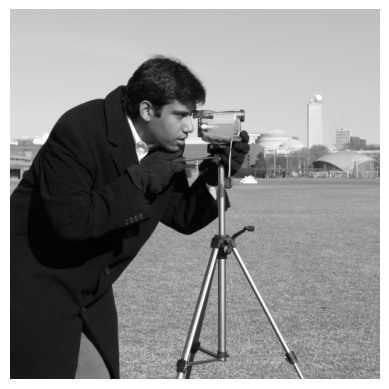

In [9]:
# ── Load image ────────────────────────────────────
# Load cameraman image from skimage and convert it to PIL
image = Image.fromarray(data.camera())

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [11]:
# Get the size of the image
width, height = image.size
# scaling factors
cx = 2
cy = 2

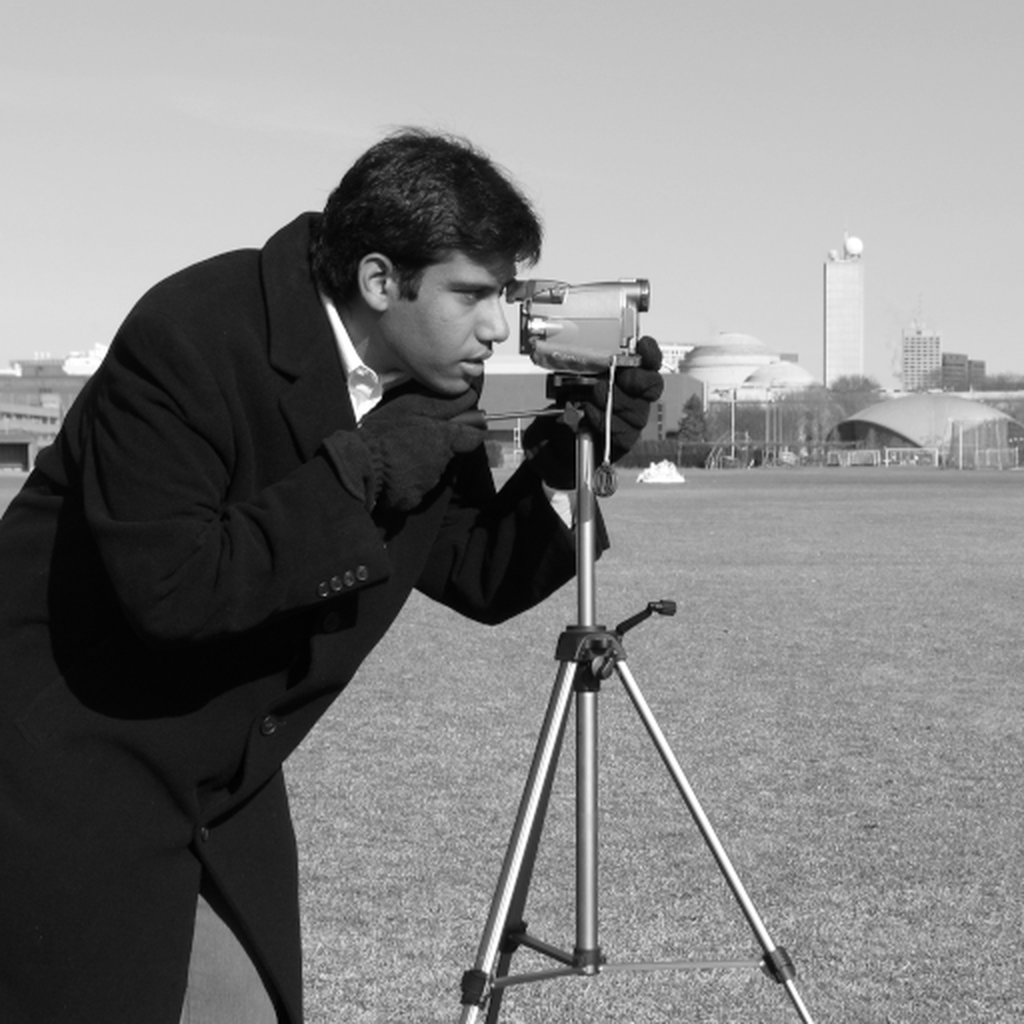

In [12]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_image = image.resize(
    (width * cx, height * cy),
    Image.Resampling.LANCZOS
)

display(scaled_image)


In [13]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_1_scaled.jpg")

print("Original size:", image.size)
print("Scaled size:", scaled_image.size)


Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [14]:
cx = 2
cy = 1

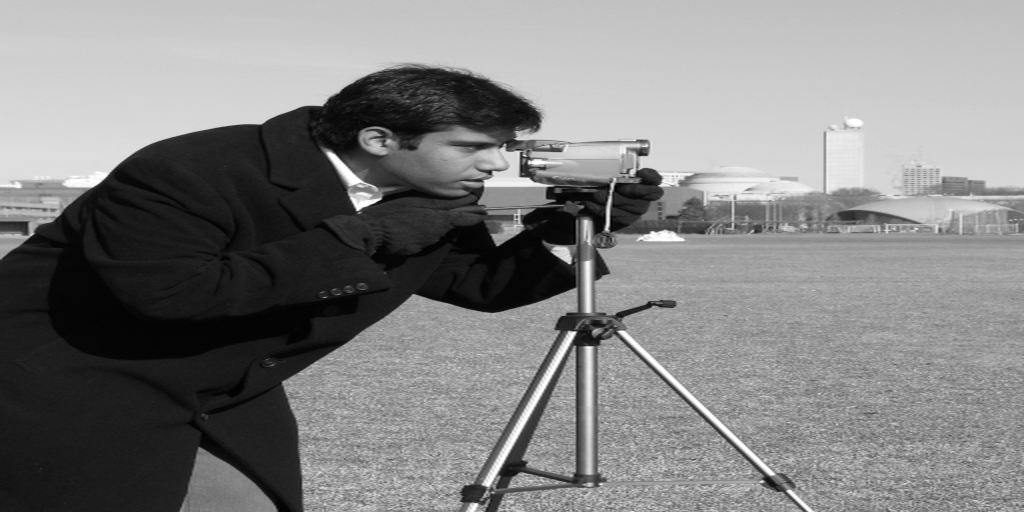

In [15]:
non_uniform_image = image.resize(
    (width * cx, height * cy),
    Image.Resampling.LANCZOS
)

display(non_uniform_image)

In [16]:
non_uniform_image.save("task1_1_nonuniform.jpg")

print("Original size:", image.size)
print("Non-uniform size:", non_uniform_image.size)

Original size: (512, 512)
Non-uniform size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


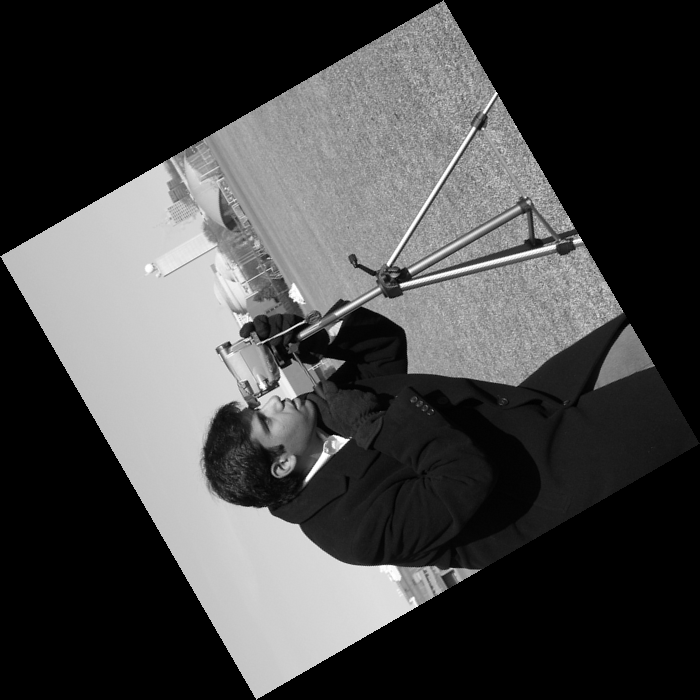

In [17]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_image = image.rotate(
    120,
    resample=Image.Resampling.BICUBIC,
    expand=True
)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image.save("task1_2_rotated.jpg")

print("Original size:", image.size)
print("Rotated size:", rotated_image.size)

display(rotated_image)

### 3. Shear

In [18]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size

print("Width:", width)
print("Height:", height)

Width: 512
Height: 512


In [19]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
shy = 0

tx = 0
ty = 0

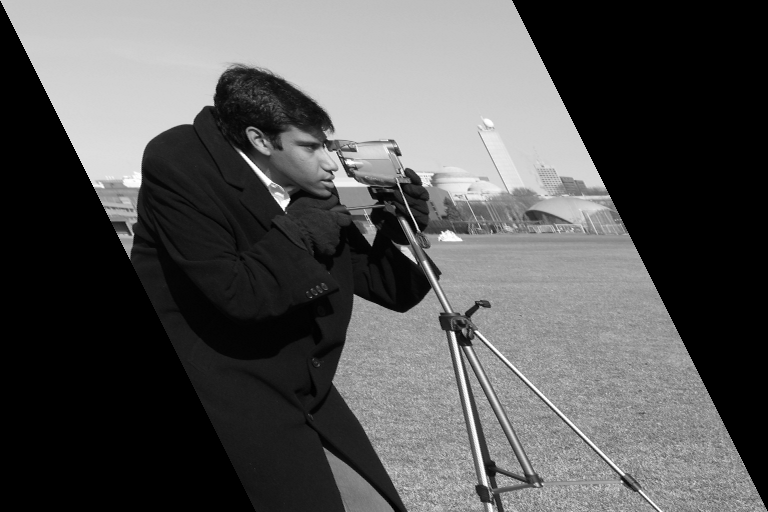

In [21]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_width = int(width + abs(shx) * height)

sheared_image = image.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    (1, -shx, tx, -shy, 1, ty),
    resample=Image.Resampling.BICUBIC
)

display(sheared_image)



In [22]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("task1_3_sheared.jpg")

print("Original size:", image.size)
print("Sheared size:", sheared_image.size)

Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

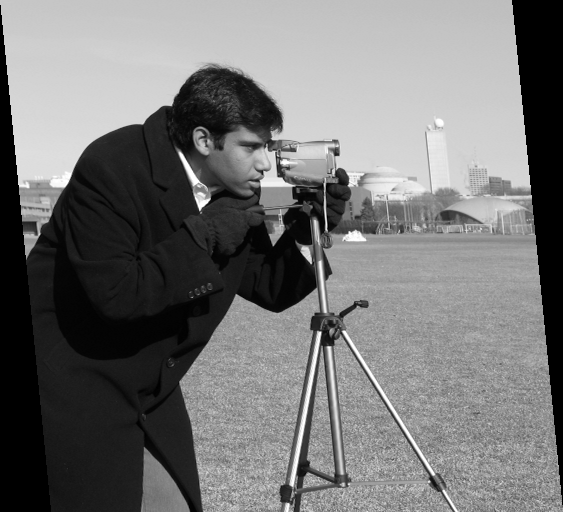

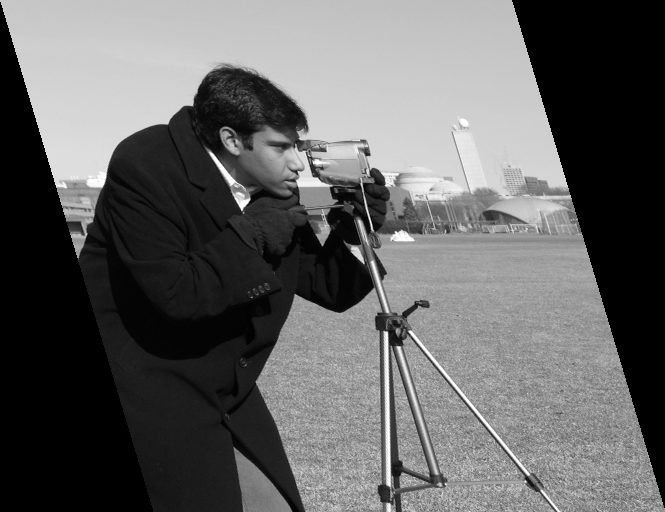

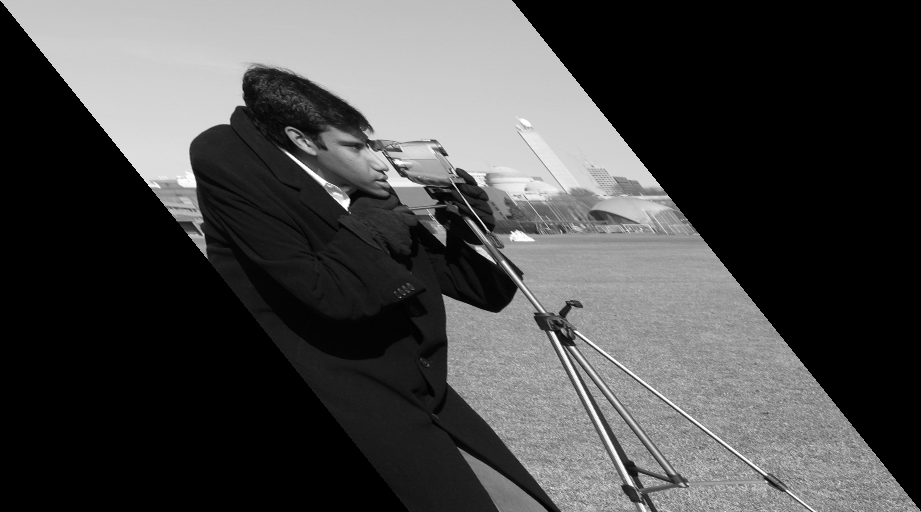

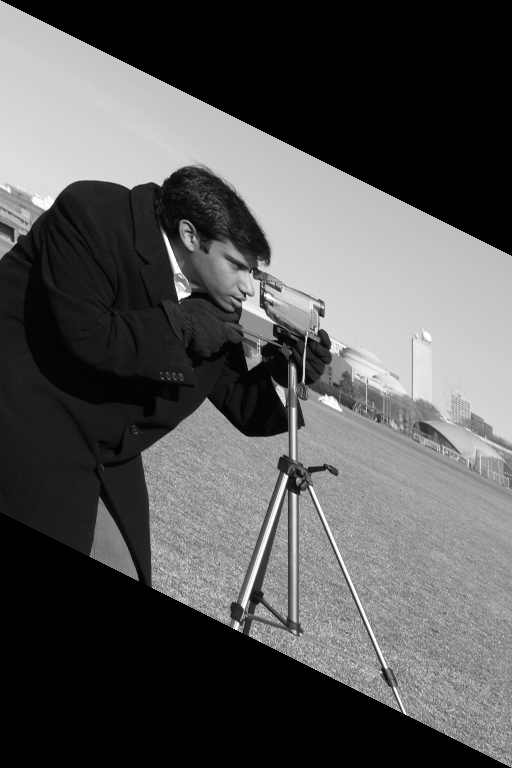

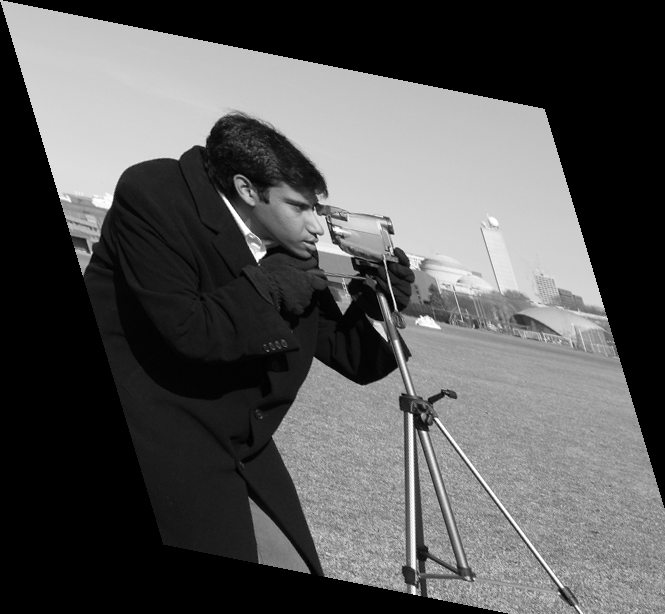

In [23]:
# Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results
for shx in [0.1, 0.3, 0.8]:

    new_width = int(width + abs(shx) * height)

    x_shear = image.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        (1, -shx, 0, 0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )

    display(x_shear)


# Switch from X-axis to Y-axis shear
shy = 0.5

new_height = int(height + abs(shy) * width)

y_shear = image.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    (1, 0, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

display(y_shear)


# Update canvas and combine X and Y shear
shx = 0.3
shy = 0.2

new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

xy_shear = image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

display(xy_shear)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

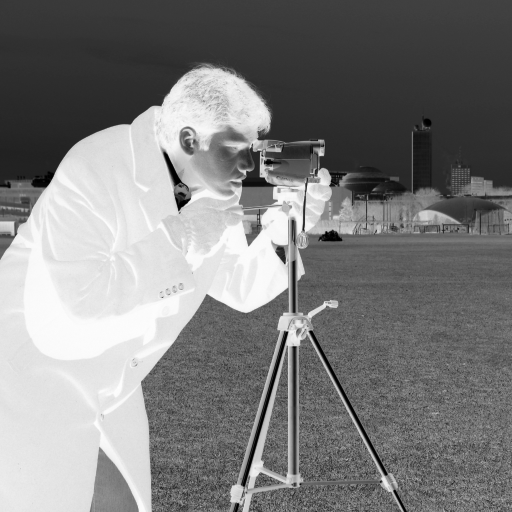

In [24]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

arr = np.array(image)

negative_arr = 255 - arr

negative_image = Image.fromarray(negative_arr.astype(np.uint8))

display(negative_image)


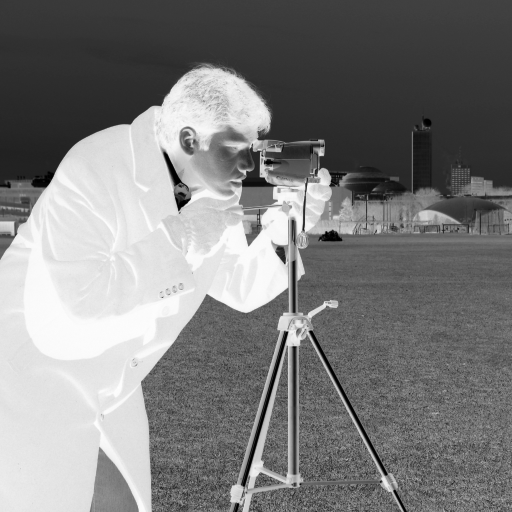

In [26]:
# Method 2: PIL's ImageOps
negative_image2 = ImageOps.invert(image)

display(negative_image2)


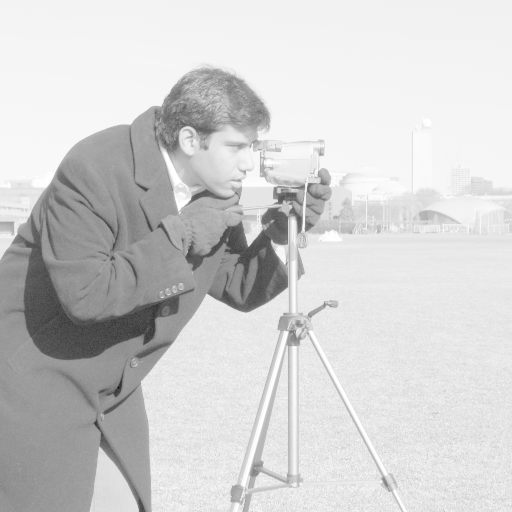

In [27]:
# ── 2. Log transformation ──────────────────────────
arr = np.array(image, dtype=np.float32)
# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)


c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)

log_transformed_arr = np.uint8(log_transformed_arr)

log_transformed_image = Image.fromarray(log_transformed_arr)

display(log_transformed_image)

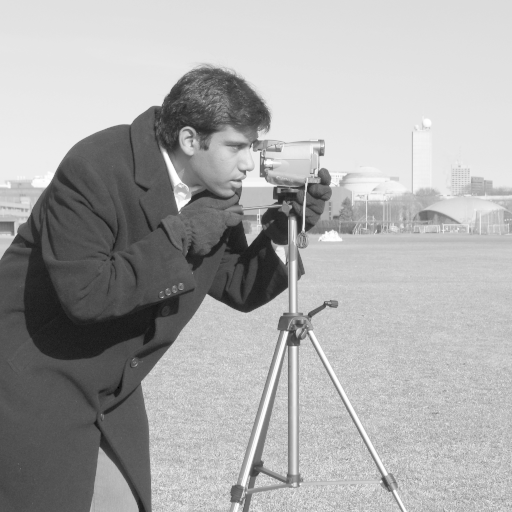

In [28]:
# ── 3. Power-law / Gamma correction ───────────────
arr = np.array(image, dtype=np.float32) / 255.0

gamma = 0.5

gamma_arr = 255 * (arr ** gamma)

gamma_arr = np.uint8(gamma_arr)

gamma_image = Image.fromarray(gamma_arr)

display(gamma_image)